# ACP des données "Caractères"

Il s'agit d'explorer les données issues de la pixellisation de tracés de caractères dont les procédés d'obtention et prétraitement sont décrits sur le site de l'UCI (Lichman, 2013). Les chiffres ont été saisies sur des tablettes à l'intérieur de cadres de résolution
. Des procédures de normalisation, ré-échantillonnage spatial puis de lissage ont été appliquées. Chaque caractère apparaît finalement discrétisé sous la forme d'une matrice 8X8
 de pixels à 16 niveaux de gris et identifié par un label. Les données sont archivées sous la forme d'une matrice ou tableau à trois indices. Elles sont également archivées après vectorisation des images sous la forme d'une matrice à
 colonnes.

L'étude du même type de données, mais nettement plus complexes (MNIST): 60 000 caractères représentés par des images de 784 pixels (26X26) fait l'objet d'un autre calepin.

## Prise en main des données

In [1]:
# Importations
import matplotlib.pyplot as plt
from sklearn import datasets
%matplotlib inline
# les données présentes dans la librairie
digits = datasets.load_digits()
# Contenu et mode d'obtention
print(digits)

{'data': array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ..., 10.,  0.,  0.],
       [ 0.,  0.,  0., ..., 16.,  9.,  0.],
       ...,
       [ 0.,  0.,  1., ...,  6.,  0.,  0.],
       [ 0.,  0.,  2., ..., 12.,  0.,  0.],
       [ 0.,  0., 10., ..., 12.,  1.,  0.]]), 'target': array([0, 1, 2, ..., 8, 9, 8]), 'frame': None, 'feature_names': ['pixel_0_0', 'pixel_0_1', 'pixel_0_2', 'pixel_0_3', 'pixel_0_4', 'pixel_0_5', 'pixel_0_6', 'pixel_0_7', 'pixel_1_0', 'pixel_1_1', 'pixel_1_2', 'pixel_1_3', 'pixel_1_4', 'pixel_1_5', 'pixel_1_6', 'pixel_1_7', 'pixel_2_0', 'pixel_2_1', 'pixel_2_2', 'pixel_2_3', 'pixel_2_4', 'pixel_2_5', 'pixel_2_6', 'pixel_2_7', 'pixel_3_0', 'pixel_3_1', 'pixel_3_2', 'pixel_3_3', 'pixel_3_4', 'pixel_3_5', 'pixel_3_6', 'pixel_3_7', 'pixel_4_0', 'pixel_4_1', 'pixel_4_2', 'pixel_4_3', 'pixel_4_4', 'pixel_4_5', 'pixel_4_6', 'pixel_4_7', 'pixel_5_0', 'pixel_5_1', 'pixel_5_2', 'pixel_5_3', 'pixel_5_4', 'pixel_5_5', 'pixel_5_6', 'pixel_5_7', 'pixel_6_0', '

In [2]:
# Dimensions
digits.images.shape

(1797, 8, 8)

In [3]:
# Sous forme d'un cube d'images 1797 x 8x8
print(digits.images)

[[[ 0.  0.  5. ...  1.  0.  0.]
  [ 0.  0. 13. ... 15.  5.  0.]
  [ 0.  3. 15. ... 11.  8.  0.]
  ...
  [ 0.  4. 11. ... 12.  7.  0.]
  [ 0.  2. 14. ... 12.  0.  0.]
  [ 0.  0.  6. ...  0.  0.  0.]]

 [[ 0.  0.  0. ...  5.  0.  0.]
  [ 0.  0.  0. ...  9.  0.  0.]
  [ 0.  0.  3. ...  6.  0.  0.]
  ...
  [ 0.  0.  1. ...  6.  0.  0.]
  [ 0.  0.  1. ...  6.  0.  0.]
  [ 0.  0.  0. ... 10.  0.  0.]]

 [[ 0.  0.  0. ... 12.  0.  0.]
  [ 0.  0.  3. ... 14.  0.  0.]
  [ 0.  0.  8. ... 16.  0.  0.]
  ...
  [ 0.  9. 16. ...  0.  0.  0.]
  [ 0.  3. 13. ... 11.  5.  0.]
  [ 0.  0.  0. ... 16.  9.  0.]]

 ...

 [[ 0.  0.  1. ...  1.  0.  0.]
  [ 0.  0. 13. ...  2.  1.  0.]
  [ 0.  0. 16. ... 16.  5.  0.]
  ...
  [ 0.  0. 16. ... 15.  0.  0.]
  [ 0.  0. 15. ... 16.  0.  0.]
  [ 0.  0.  2. ...  6.  0.  0.]]

 [[ 0.  0.  2. ...  0.  0.  0.]
  [ 0.  0. 14. ... 15.  1.  0.]
  [ 0.  4. 16. ... 16.  7.  0.]
  ...
  [ 0.  0.  0. ... 16.  2.  0.]
  [ 0.  0.  4. ... 16.  2.  0.]
  [ 0.  0.  5. ... 12.  0.  

In [4]:
# Sous forme d'une matrice 1797 x 64
print(digits.data)

[[ 0.  0.  5. ...  0.  0.  0.]
 [ 0.  0.  0. ... 10.  0.  0.]
 [ 0.  0.  0. ... 16.  9.  0.]
 ...
 [ 0.  0.  1. ...  6.  0.  0.]
 [ 0.  0.  2. ... 12.  0.  0.]
 [ 0.  0. 10. ... 12.  1.  0.]]


In [5]:
# Label réel de chaque caractère
print(digits.target)

[0 1 2 ... 8 9 8]


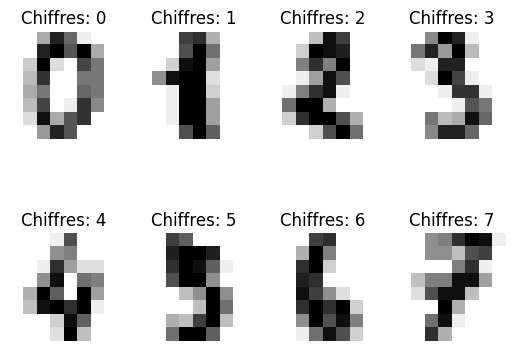

In [7]:
# Voici un aperçu des empilements des images à décrire puis ensuite en principe à discriminer:
images_and_labels = list(zip(digits.images,
   digits.target))
for index, (image, label) in  enumerate(images_and_labels[:8]):
     plt.subplot(2, 4, index + 1)
     plt.axis('off')
     plt.imshow(image, cmap=plt.cm.gray_r, interpolation='nearest')
     plt.title('Chiffres: %i' % label)

## Analyse en composantes principales

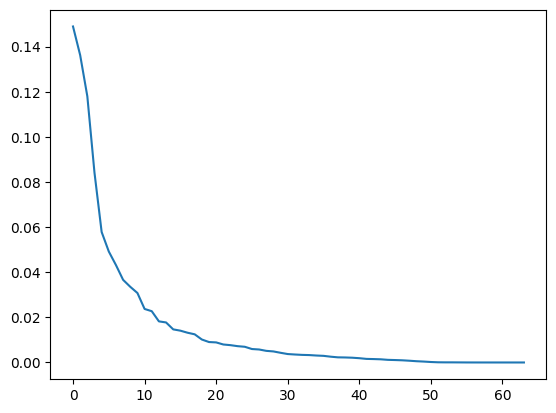

In [8]:
from sklearn.decomposition import PCA
X=digits.data
y=digits.target
target_name=[0,1,2,3,4,5,6,7,8,9]
# définition de la commande
pca = PCA()
# Estimation, calcul des composantes principales
C = pca.fit(X).transform(X)
# Décroissance de la variance expliquée
plt.plot(pca.explained_variance_ratio_)
plt.show()

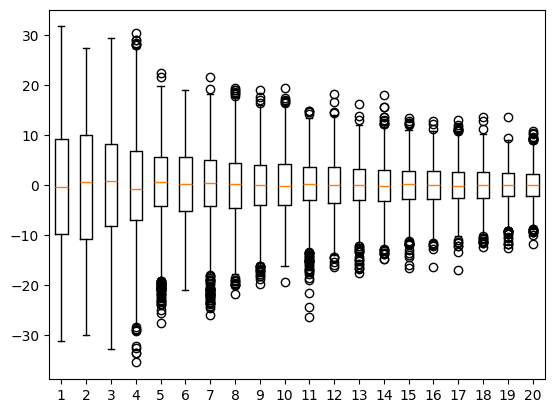

In [9]:
# Diagramme boîte des premières composantes principales.
plt.boxplot(C[:,0:20])
plt.show()

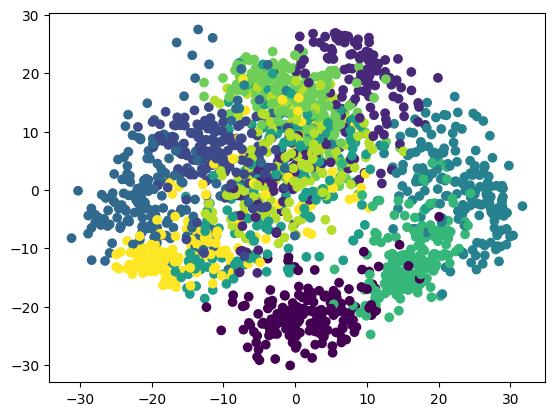

In [10]:
plt.scatter(C[:,0], C[:,1], c=y, label=target_name)
plt.show()

Ce graphique est un nuage de points où chaque point représente un caractère numérique. L'axe horizontal (C[:,0]) correspond à la première composante principale et l'axe vertical (C[:,1]) à la deuxième composante principale. Les points sont colorés en fonction du chiffre réel qu'ils représentent (0 à 9). On peut observer que certaines classes de chiffres sont bien regroupées et distinctes les unes des autres, tandis que d'autres se chevauchent, ce qui indique que les deux premières composantes principales ne sont pas suffisantes pour parfaitement séparer tous les chiffres.



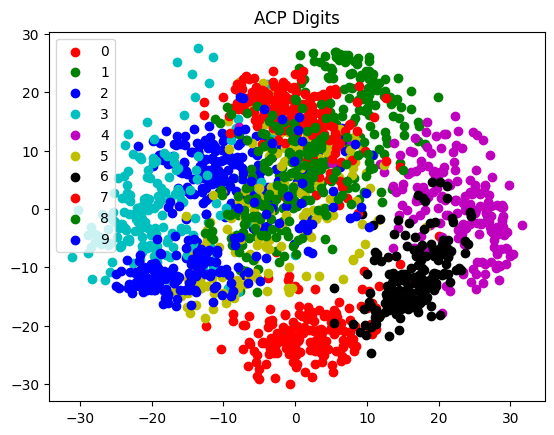

In [19]:
# attention aux indentations
plt.figure()
# Correction: La variable 'target_name' a été écrasée. Utilisons directement digits.target_names.
# Le troisième argument dans zip est maintenant omis et 'i' est utilisé pour le label.
for c, i in zip("rgbcmykrgb", digits.target_names):
       plt.scatter(C[y == i,0], C[y == i,1], c=c, label=i)
plt.legend()
plt.title("ACP Digits")
plt.show()

/tmp/ipython-input-3686265366.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


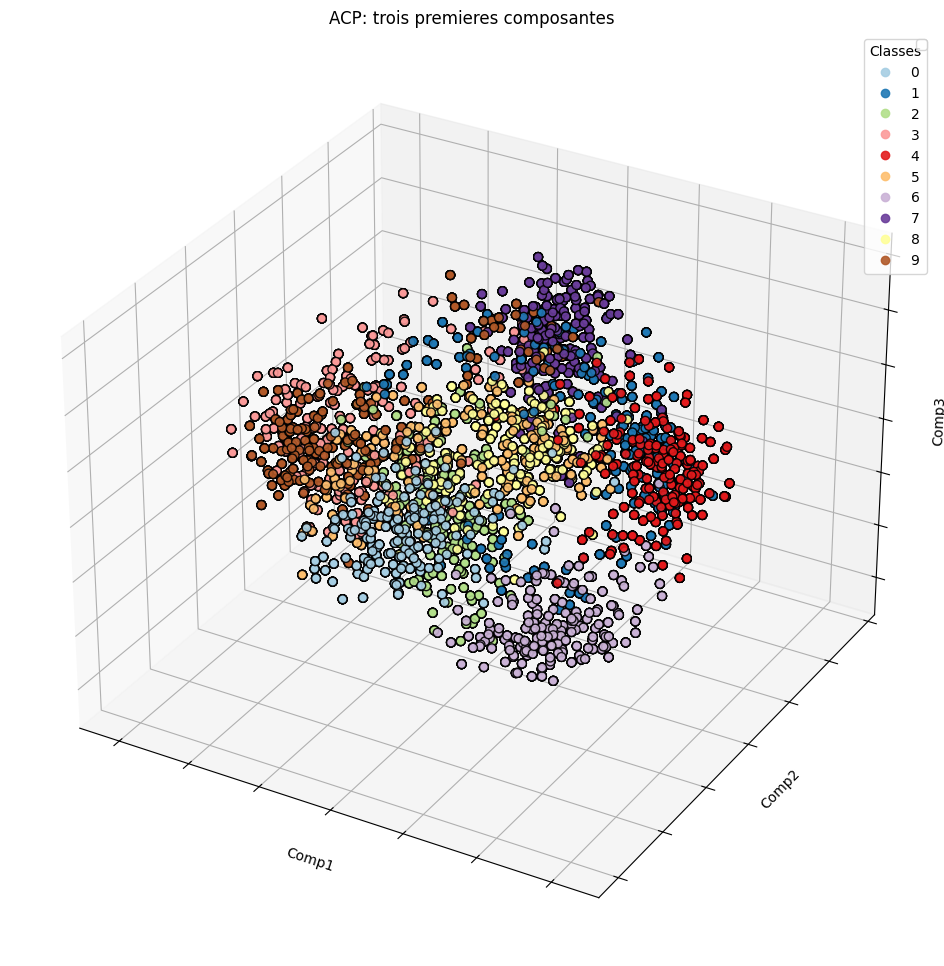

In [41]:
# Graphique en trois dimensions.
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
fig = plt.figure(1, figsize=(18, 12))
ax = fig.add_subplot(111, projection='3d')
classes = np.unique(y)
for cls in classes:
 sc= ax.scatter(C[:, 0], C[:, 1], C[:, 2], c=y, cmap=plt.cm.Paired,edgecolor='k', alpha=0.9, s=40)
legend1 = ax.legend(*sc.legend_elements(), title="Classes")
ax.add_artist(legend1)
ax.set_title("ACP: trois premieres composantes")
ax.set_xlabel("Comp1")
ax.set_xticklabels([])  # Correction: Utilisation de set_xticklabels directement
ax.set_ylabel("Comp2")
ax.set_yticklabels([])  # Correction: Utilisation de set_yticklabels directement
ax.set_zlabel("Comp3")
ax.set_zticklabels([])  # Correction: Utilisation de set_zticklabels directement
plt.legend()
plt.show()

Ce graphique en trois dimensions représente les données des caractères numériques projetées sur les trois premières composantes principales (Comp1, Comp2, Comp3). Chaque point correspond à un caractère, et sa couleur indique le chiffre réel qu'il représente (de 0 à 9). Par rapport à la visualisation en 2D, l'ajout de la troisième composante principale peut aider à mieux distinguer certaines classes de chiffres qui se chevauchaient auparavant. On peut observer comment les différents chiffres se regroupent, formant des clusters plus ou moins distincts, et identifier les chiffres qui restent difficiles à séparer même dans cet espace à trois dimensions. Cette visualisation est utile pour comprendre la structure sous-jacente des données et évaluer dans quelle mesure ces trois composantes sont discriminantes.



# Données "cubiques" de l'OCDE

**Objectif**

L'objectif de cette section est l'exploration de données socio-économiques plus complexes. La principale spécificité de ces données est de se présenter sous la forme d'un cube de données ou tableau à trois entrées: le numéro de ligne, le numéro de variable et l'année d'observation de cette variable. Après une description classique, la mise en oeuvre de l'analyse en composantes principales avec python nécessite un effort particulier afin de produire les graphes adaptés à la structure particulière des données.

Les données
Les données sont issues de l'Observatoire de l'OCDE. Pour chaque pays membre et pour chacune des années 1975, 1977, 1979, 1981, on connaît les valeurs prises par les variables suivantes qui sont toutes des \emph{taux}~:

- Taux brut de natalité,
- Taux de chômage,
- Pourcentage d'actifs dans le secteur primaire,
- Pourcentage d'actifs dans le secteur secondaire,
- produit intérieur brut (par habitant),
- Formation brute de capital fixe (par habitant),
- Hausse des prix,
- Recettes courantes (par habitant),
- Mortalité infantile,
- Consommation de protéines animales (par habitant),
- Consommation d'énergie (par habitant).

Les mêmes variables sont donc observées, sur les mêmes pays ou individus à quatre dates différentes. Plusieurs stratégies d'analyse sont possibles (tableau moyen, tableaux concaténés, meilleur compromis ou double ACP). La plus adaptée pour ces données est de considérer les observations des variables pour chacun des individus: pays X années.

In [42]:
# Importation des principals librairies et
# Affichage des graphiques dans le notebook
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [43]:
ocde=pd.read_csv("https://www.math.univ-toulouse.fr/~besse/Wikistat/Data/ocde.txt",sep='\s+',header=0)
ocde.head()

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-372622539.py:1: SyntaxWarning: invalid escape sequence '\s'
  ocde=pd.read_csv("https://www.math.univ-toulouse.fr/~besse/Wikistat/Data/ocde.txt",sep='\s+',header=0)


,TxNat,TxCho,PcPri,PcSec,Pib,Fcpe,Infl,Recc,MorIn,CProt,CNRJ
AL1,97,41,73,460,6870,211,60,409,197,58,394
AL2,95,40,68,453,8410,209,48,435,155,65,425
AL3,95,33,62,449,12450,227,41,427,147,67,463
AL4,101,44,55,435,11076,220,47,446,126,68,427
AU1,123,17,125,409,4990,267,78,391,205,56,307


In [44]:
ocde.mean()

,0
TxNat,140.117647
TxCho,53.882353
PcPri,107.147059
PcSec,351.294118
Pib,7574.352941
Fcpe,227.691176
Infl,109.558824
Recc,403.250000
MorIn,135.882353
CProt,60.500000


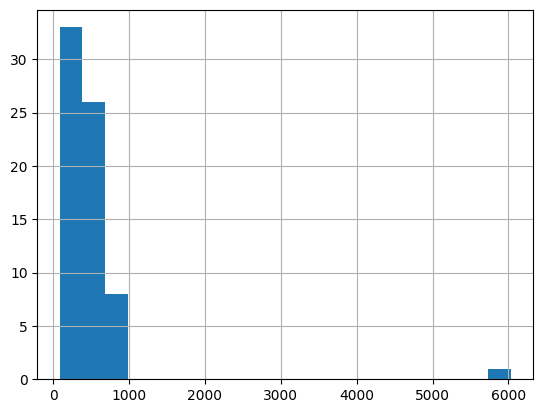

In [45]:
ocde["CNRJ"].hist(bins=20)
plt.show()

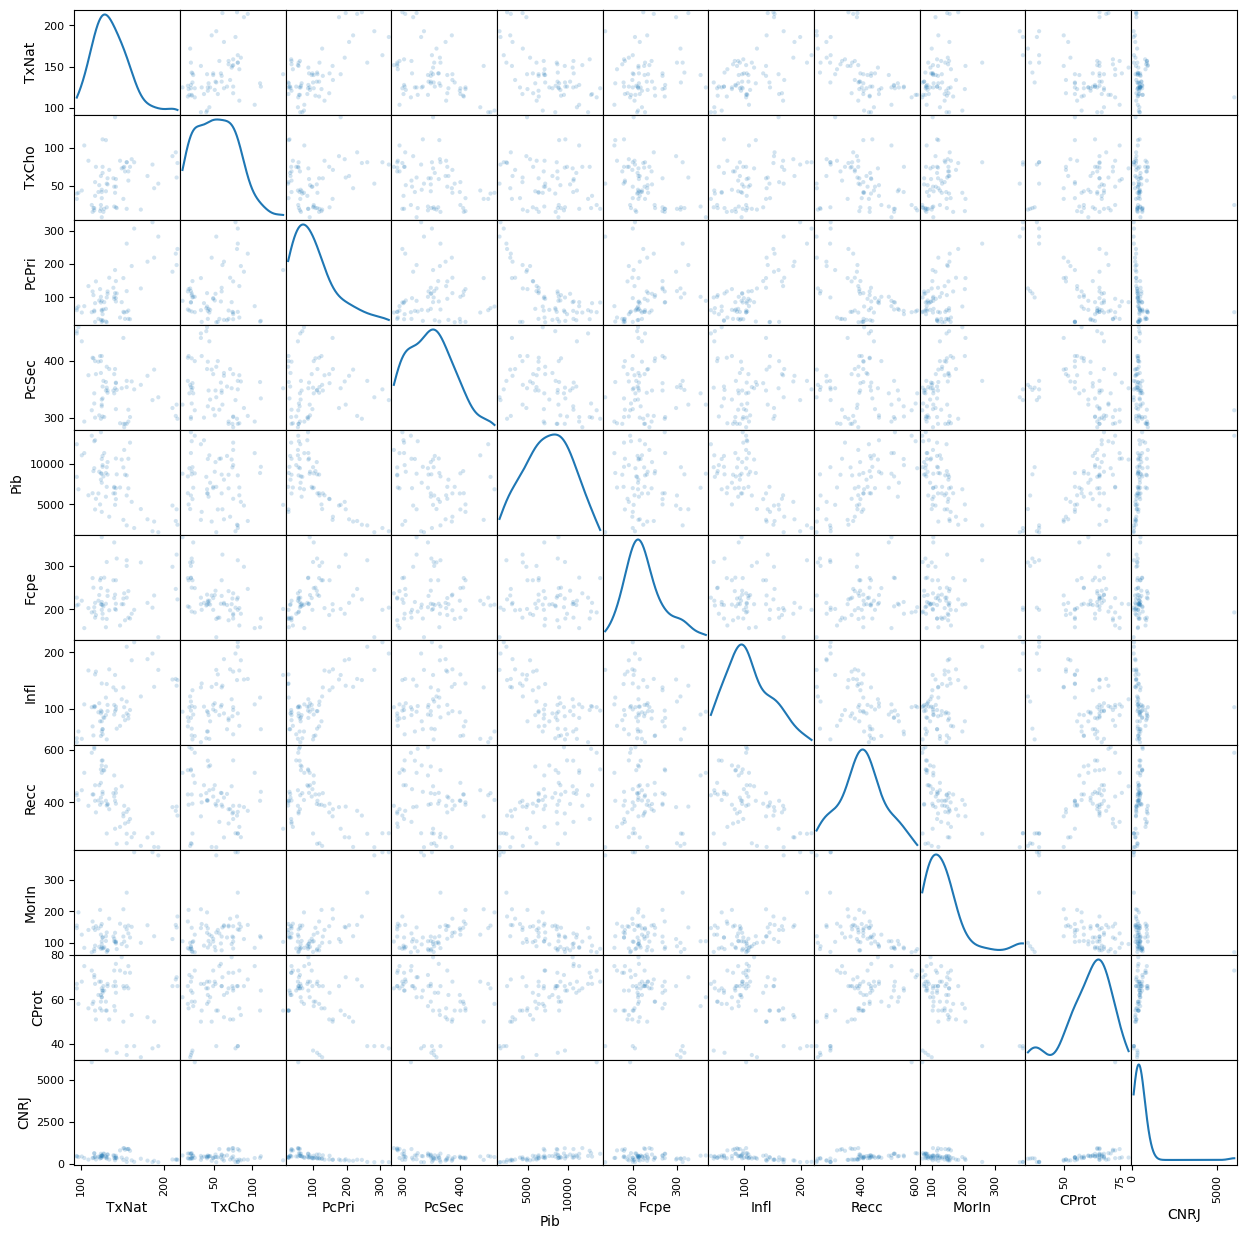

In [46]:
from pandas.plotting import scatter_matrix
scatter_matrix(ocde, alpha=0.2, figsize=(15, 15), diagonal='kde')
plt.show()

# ACP

Chaque pays étant observé 4 fois, la principale difficulté technique est de faire apparaître cette structure chronologique dans les graphique afin d'illustrer la dynamique économique de la période considérée.

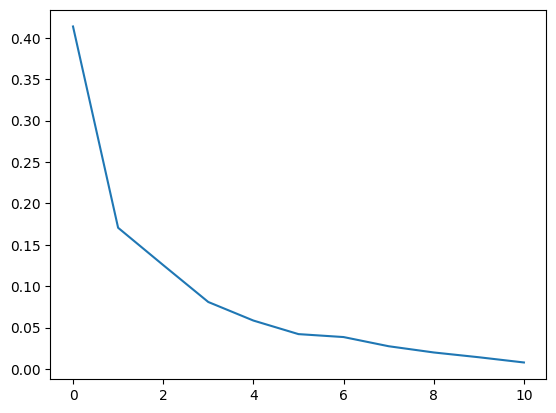

In [52]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import scale
# réduction
ocdeS=scale(ocde)
pca = PCA()
cpOcde = pca.fit_transform(ocdeS)
# Eboulis
plt.plot(pca.explained_variance_ratio_)
plt.show()

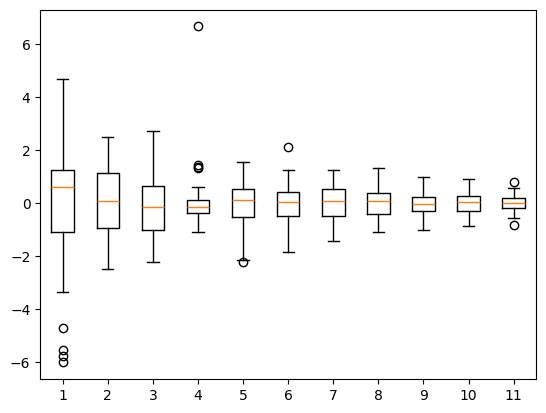

In [53]:
plt.boxplot(cpOcde)
plt.show()

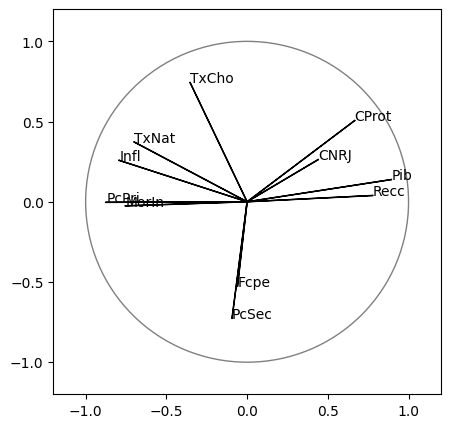

In [54]:
# Représentation des variables
coord1=pca.components_[0]*np.sqrt(pca.explained_variance_[0])
coord2=pca.components_[1]*np.sqrt(pca.explained_variance_[1])
fig = plt.figure(figsize=(5,5))
ax = fig.add_subplot(1, 1, 1)
for i, j, nom in zip(coord1,coord2, ocde.columns):
    plt.text(i, j, nom)
    plt.arrow(0,0,i,j,color='black')
plt.axis((-1.2,1.2,-1.2,1.2))
# cercle
c=plt.Circle((0,0), radius=1, color='gray', fill=False)
ax.add_patch(c)
plt.show()

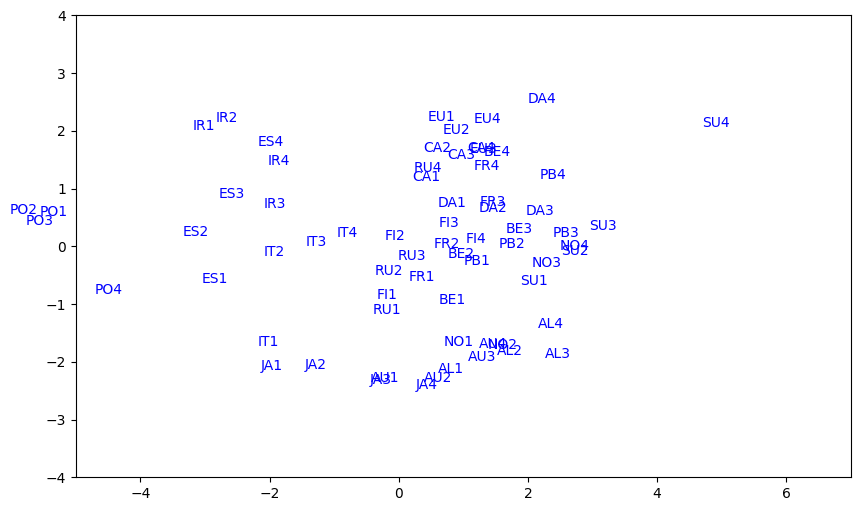

In [55]:
plt.figure(figsize=(10,6))
for i, j, nom in zip(cpOcde[:,0], cpOcde[:,1], ocde.index):
#    color = int(i/4)
    plt.text(i, j, nom ,color="blue")
plt.axis((-5,7,-4,4))
plt.show()

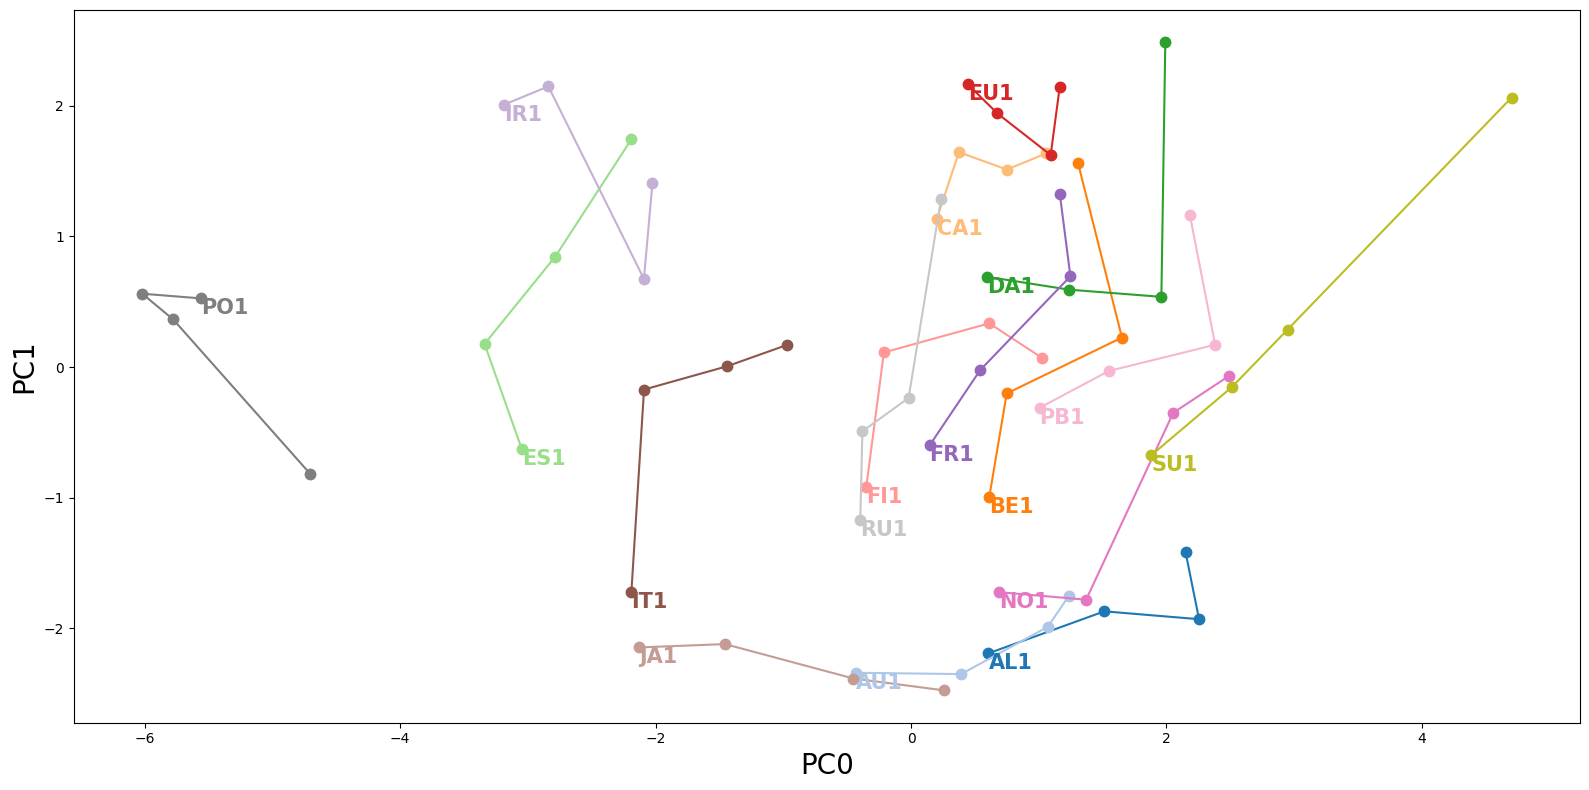

In [56]:
import matplotlib.patheffects as PathEffects

comp_0 = 0
comp_1 = 1

cmap = plt.get_cmap("tab20")

fig = plt.figure(figsize=(16,8))
ax = fig.add_subplot(1,1,1)
for i,k in enumerate(np.arange(0,cpOcde.shape[0],4)):
    country =ocde.index[k]
    xs = cpOcde[k:k+4,comp_0]
    ys = cpOcde[k:k+4, comp_1]
    ax.plot(xs,ys, color=cmap(i), marker=".", markersize=15)
    txt = ax.text(xs[-4], ys[-4], country, horizontalalignment="left", verticalalignment="top",
            color=cmap(i), fontweight="bold", fontsize=15)
    # Add black line around text
    #txt.set_path_effects([PathEffects.withStroke(linewidth=1, foreground='black')])
    ax.set_xlabel("PC%d" %comp_0, fontsize=20)
    ax.set_ylabel("PC%d" %comp_1, fontsize=20)
plt.tight_layout()
plt.show()

Pour une interprétation plus approfondie du graphique des trajectoires des pays de l'OCDE dans l'espace des deux premières composantes principales, voici ce que l'on peut analyser :

Signification des Axes (Composantes Principales):

Les axes PC0 et PC1 sont des combinaisons linéaires des variables d'origine (taux de natalité, chômage, PIB, etc.). Pour une interprétation précise, il faudrait regarder le cercle des corrélations (représentation des variables) que nous avons généré précédemment. Généralement, la PC0 explique la plus grande part de variance et peut représenter un facteur global de développement économique ou de taille. La PC1, quant à elle, pourrait capturer une autre dimension importante, comme une opposition entre certains types d'économies ou des phases de développement.
Longueur et Direction des Trajectoires:

Trajectoires Longues : Un pays avec une trajectoire longue (par exemple, TU pour la Turquie, GR pour la Grèce ou PO pour le Portugal) indique des changements significatifs dans son profil socio-économique au cours de la période 1975-1981. Ces pays ont connu une évolution rapide ou une transformation importante par rapport aux autres.
Trajectoires Courtes : Inversement, des trajectoires courtes (comme pour les pays scandinaves ou l'Allemagne) suggèrent une plus grande stabilité relative de leurs structures socio-économiques sur cette période, ou une évolution plus lente et moins prononcée.
Direction : La direction des flèches (ou le sens des points successifs) est cruciale. Elle montre l'orientation des changements. Par exemple, si l'axe PC0 est lié au développement économique, un mouvement vers la droite (si la PC0 représente le développement positif) indiquerait une croissance ou une modernisation.
Regroupement des Pays (Clustering):

Les pays dont les trajectoires sont proches ou se croisent dans le graphique partagent des profils ou des dynamiques socio-économiques similaires. On peut identifier des groupes de pays ayant des caractéristiques ou des évolutions comparables. Par exemple, on peut voir des groupes de pays industrialisés stables vs. des pays en développement rapide.
Certains pays peuvent rester isolés, indiquant des profils uniques ou des trajectoires très différentes des autres.
Évolution dans le Temps:

Chaque point sur la trajectoire représente une année d'observation (1975, 1977, 1979, 1981). En suivant les points, on peut visualiser la vitesse et la nature du changement année après année pour chaque pays.
Si des trajectoires convergent vers une même région du plan, cela pourrait suggérer une convergence économique ou sociale entre ces pays. Si elles divergent, cela indique une augmentation des différences.